In [1]:
from main import *
from Utils.plotting_functions import *
from Worlds.World import World
import Drone.Simulation
from matplotlib import pyplot as plt
from Optimizations.PSO_optimizer import PSOOptimizer

parameters = load_parameters("Settings/simulation_parameters.yaml")

A = parameters['start_point']
B = parameters['end_point']

init_state = create_initial_state(A[0], A[1], A[2])

# waypoints = [
#     {"x": 700, "y": 300, "z": 500, "v": 15},
# ]

# waypoints.append({"x": B[0], "y": B[1], "z": B[2], "v": 5})

thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

In [ ]:
sim = Simulation(
    drone,
    world,
    waypoints=[], 
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=False,
    compute_psychoacoustics=False,
    noise_annoyance_radius=9,
)

optimizer = PSOOptimizer(
    simulation_object = sim,
    config_file = None,
    A = parameters['start_point'],
    B = parameters['end_point'],
)

# optimizer.simulation_object.startSimulation(stop_at_target=True, use_static_target=False, verbose=True)
# costs = optimizer.calculate_costs(weight_penalties=True, save_costs_in_history=False)
# print(f"Total costs: {costs}")

[ PSO ]> No configuration file provided, using default settings.


In [3]:
# noise_penalty_history = np.array(optimizer.simulation_object.noise_penalty_history)
# spl = np.array(optimizer.simulation_object.spl_history, dtype=float)
# spl_weighted = spl * noise_penalty_history

# # Plot a histogram of sound power levels vs simulation time (3 bars, unweighted, weighted by noise penalty and noise penalty values)
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 3, 1)
# plt.bar(np.arange(len(spl)), spl, color='blue', alpha=0.7)
# plt.title(f'Unweighted - mean: {np.mean(spl):.2f}')
# plt.ylim(0, max(spl)*1.1)
# plt.xlabel('Simulation Time')
# plt.ylabel('Sound Power Level')

# plt.subplot(1, 3, 2)
# plt.bar(np.arange(len(spl_weighted)), spl_weighted, color='orange', alpha=0.7)
# plt.title(f'Weighted - mean: {np.mean(spl_weighted):.2f}')
# plt.ylim(0, max(spl_weighted)*1.1)
# plt.xlabel('Simulation Time')
# plt.ylabel('Sound Power Level')

# plt.subplot(1, 3, 3)
# plt.bar(np.arange(len(noise_penalty_history)), noise_penalty_history, color='green', alpha=0.7)
# plt.title('Noise Penalty Values')
# plt.xlabel('Simulation Time')
# plt.ylabel('Noise Penalty')

# plt.tight_layout()
# plt.show()


In [4]:
# waypoints_list = [(x,y,z) for x,y,z in [(wp['x'], wp['y'], wp['z']) for wp in waypoints]]
# del waypoints_list[-1]
# show2DWorld(
#     world, optimizer.simulation_object.positions, A, B, waypoints_list)

[ PSO ]> Gen 1/100, Particle 1/30, Cost: 3817.11, best: 3817.11
[ PSO ]> Gen 1/100, Particle 2/30, Cost: 2192.00, best: 2192.00
[ PSO ]> Gen 1/100, Particle 3/30, Cost: 2652.73, best: 2192.00
[ PSO ]> Gen 1/100, Particle 4/30, Cost: 3327.36, best: 2192.00
[ PSO ]> Gen 1/100, Particle 5/30, Cost: 2640.88, best: 2192.00
[ PSO ]> Gen 1/100, Particle 6/30, Cost: 2179.19, best: 2179.19
[ PSO ]> Gen 1/100, Particle 7/30, Cost: 1570.01, best: 1570.01
[ PSO ]> Gen 1/100, Particle 8/30, Cost: 1822.99, best: 1570.01
[ PSO ]> Gen 1/100, Particle 9/30, Cost: 2000.80, best: 1570.01
[ PSO ]> Gen 1/100, Particle 10/30, Cost: 2618.69, best: 1570.01
[ PSO ]> Gen 1/100, Particle 11/30, Cost: 1661.15, best: 1570.01
[ PSO ]> Gen 1/100, Particle 12/30, Cost: 2498.77, best: 1570.01
[ PSO ]> Gen 1/100, Particle 13/30, Cost: 1466.74, best: 1466.74
[ PSO ]> Gen 1/100, Particle 14/30, Cost: 1591.02, best: 1466.74
[ PSO ]> Gen 1/100, Particle 15/30, Cost: 667.22, best: 667.22
[ PSO ]> Gen 1/100, Particle 16/30, 

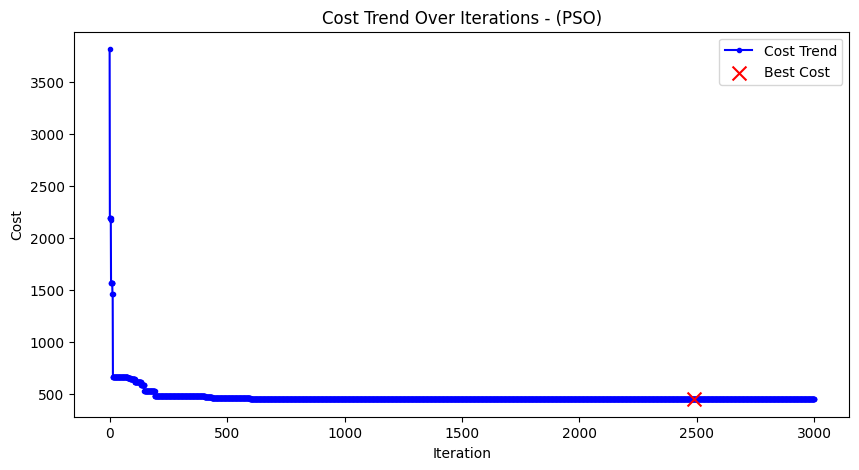

In [5]:
optimizer.start_optimization()